# 02 — Existing EV Charging Stations (Baseline)

**Objective:** Load Spain's existing public EV charging infrastructure from the National Access Point (NAP) and filter to stations on or near interurban roads. This establishes the **baseline** — we only propose new stations where gaps exist.

**Data source:** [NAP — EV Charging Points](https://nap.dgt.es/en/dataset/puntos-de-recarga-electrica-para-vehiculos) (DATEX2v3 XML, updated daily)

**Fallback:** [OpenChargeMap API](https://openchargemap.org/site/develop/api)

**Output:** `data/processed/existing_chargers_interurban.csv`


In [5]:
# Install dependencies (Colab)
# !pip install geopandas requests lxml shapely -q

import geopandas as gpd
import pandas as pd
import numpy as np
import requests
import xml.etree.ElementTree as ET
from io import BytesIO
import os
import warnings
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')
print("Libraries loaded.")


Libraries loaded.


## 1. Download NAP charging data

The official DATEX2v3 endpoint publishes all public EV charging points in Spain.
The XML uses nested namespaces — we parse `energyInfrastructureSite` elements,
extracting coordinates from `coordinatesForDisplay` and connector counts from `refillPoint`.


In [6]:
# ── Download NAP DATEX2 XML ──

NAP_URL = "https://infocar.dgt.es/datex2/v3/miterd/EnergyInfrastructureTablePublication/electrolineras.xml"

print("Downloading NAP charging data (DATEX2v3 XML)...")
print(f"URL: {NAP_URL}")

resp_nap = None
try:
    resp_nap = requests.get(NAP_URL, timeout=120)
    print(f"Status: {resp_nap.status_code}, Size: {len(resp_nap.content) / 1024 / 1024:.1f} MB")

    if resp_nap.status_code == 200:
        os.makedirs("../data/raw", exist_ok=True)
        with open("../data/raw/nap_chargers.xml", 'wb') as f:
            f.write(resp_nap.content)
        print("Saved raw XML -> data/raw/nap_chargers.xml")
    else:
        print(f"NAP download failed: {resp_nap.status_code}")
        resp_nap = None
except Exception as e:
    print(f"NAP download error: {e}")
    resp_nap = None


URL: https://infocar.dgt.es/datex2/v3/miterd/EnergyInfrastructureTablePublication/electrolineras.xml
Status: 200, Size: 79.5 MB
Saved raw XML -> data/raw/nap_chargers.xml


In [7]:
# ── Parse DATEX2v3 XML — extract charging sites ──
# Structure (verified from actual XML):
#   payload > energyInfrastructureTable > energyInfrastructureSite
#     ├── fac:name > com:values > com:value  (station name)
#     ├── fac:locationReference > loc:coordinatesForDisplay
#     │     ├── loc:latitude
#     │     └── loc:longitude
#     └── egi:energyInfrastructureStation > egi:refillPoint > egi:connector

chargers_list = []

if resp_nap and resp_nap.status_code == 200:
    print("Parsing DATEX2v3 XML...")

    # Collect all namespaces from the document
    ns = {}
    for event, elem in ET.iterparse(BytesIO(resp_nap.content), events=['start-ns']):
        prefix, uri = elem
        if prefix:
            ns[prefix] = uri
        else:
            ns['d2'] = uri  # default namespace

    print(f"Namespaces: {list(ns.keys())}")

    # Re-parse from scratch
    root = ET.fromstring(resp_nap.content)

    # Find all energyInfrastructureSite elements (the top-level per-location unit)
    # They can be under any namespace prefix, so we search by local name
    site_tag_suffix = 'energyInfrastructureSite'
    sites = [el for el in root.iter() if el.tag.endswith(site_tag_suffix)]
    print(f"Found {len(sites)} energyInfrastructureSite elements")

    for site in sites:
        site_id = site.get('id', '')
        lat, lon = None, None
        name_text = ''
        n_connectors = 0

        # Walk all descendants of this site
        for child in site.iter():
            tag_local = child.tag.split('}')[-1] if '}' in child.tag else child.tag

            # Coordinates: inside coordinatesForDisplay
            if tag_local == 'coordinatesForDisplay':
                for coord_child in child:
                    ctag = coord_child.tag.split('}')[-1] if '}' in coord_child.tag else coord_child.tag
                    if ctag == 'latitude' and coord_child.text:
                        lat = float(coord_child.text)
                    elif ctag == 'longitude' and coord_child.text:
                        lon = float(coord_child.text)

            # Station name: inside fac:name > com:values > com:value
            if tag_local == 'name':
                # Dig into values/value
                for v in child.iter():
                    vt = v.tag.split('}')[-1] if '}' in v.tag else v.tag
                    if vt == 'value' and v.text:
                        name_text = v.text.strip()
                        break  # take the first one

            # Connector count: each refillPoint has connectors
            if tag_local == 'connector':
                n_connectors += 1

        if lat is not None and lon is not None:
            chargers_list.append({
                'station_id': site_id,
                'name': name_text,
                'latitude': lat,
                'longitude': lon,
                'n_connectors': max(n_connectors, 1),
            })

    print(f"\nExtracted {len(chargers_list)} charging stations with coordinates")
    if chargers_list:
        print(f"  Sample: {chargers_list[0]}")

if not chargers_list:
    print("DATEX2 parsing yielded 0 results. Will try OpenChargeMap fallback...")


Parsing DATEX2v3 XML...
Namespaces: ['d2', 'com', 'loc', 'roa', 'egi', 'prk', 'comx', 'fac', 'locx', 'vms', 'sit', 'xsi']
Found 12075 energyInfrastructureSite elements

Extracted 12075 charging stations with coordinates
  Sample: {'station_id': 'OPMCKAGOAIX9NOFSBUXT', 'name': 'ES*AEQ*ESAEQECM88912', 'latitude': 40.28838, 'longitude': -4.020607, 'n_connectors': 2}


## Fallback: OpenChargeMap API

If DATEX2 parsing fails (format changes, server down), [OpenChargeMap](https://openchargemap.org/) provides a clean REST API with worldwide charging station data.


In [ ]:
# ── Fallback: OpenChargeMap API for Spain ──

if not chargers_list:
    print("Using OpenChargeMap API for Spain...")

    OCM_URL = "https://api.openchargemap.io/v3/poi/"
    params = {
        "output": "json",
        "countrycode": "ES",
        "maxresults": 10000,
        "compact": True,
        "verbose": False,
    }

    try:
        resp_ocm = requests.get(OCM_URL, params=params, timeout=120)
        print(f"Status: {resp_ocm.status_code}")

        if resp_ocm.status_code == 200:
            data_ocm = resp_ocm.json()
            print(f"Retrieved {len(data_ocm)} charging locations")

            for poi in data_ocm:
                addr = poi.get("AddressInfo", {})
                lat = addr.get("Latitude")
                lon = addr.get("Longitude")
                title = addr.get("Title", "")
                n_points = poi.get("NumberOfPoints") or 1

                if lat and lon:
                    chargers_list.append({
                        'station_id': f"OCM_{poi.get('ID', '')}",
                        'name': title,
                        'latitude': lat,
                        'longitude': lon,
                        'n_connectors': n_points,
                    })

            print(f"Total stations extracted: {len(chargers_list)}")
        else:
            print(f"OpenChargeMap failed: {resp_ocm.text[:300]}")
    except Exception as e:
        print(f"OpenChargeMap error: {e}")

print(f"\n==> Total charging stations loaded: {len(chargers_list)}")


In [8]:
# ── Build GeoDataFrame ──

if chargers_list:
    df_chargers = pd.DataFrame(chargers_list)
    gdf_chargers = gpd.GeoDataFrame(
        df_chargers,
        geometry=gpd.points_from_xy(df_chargers.longitude, df_chargers.latitude),
        crs="EPSG:4326"
    )

    # Quick sanity: filter to Spain bounding box
    spain_mask = (
        (gdf_chargers.latitude >= 27) & (gdf_chargers.latitude <= 44) &
        (gdf_chargers.longitude >= -19) & (gdf_chargers.longitude <= 5)
    )
    n_before = len(gdf_chargers)
    gdf_chargers = gdf_chargers[spain_mask].copy()
    if n_before != len(gdf_chargers):
        print(f"Removed {n_before - len(gdf_chargers)} stations outside Spain bbox")

    print(f"Charging stations: {len(gdf_chargers)}")
    print(f"Total connectors:  {gdf_chargers['n_connectors'].sum()}")
    print(f"Bounding box:      {gdf_chargers.total_bounds}")
    print(f"\nSample:")
    print(gdf_chargers[['station_id','name','latitude','longitude','n_connectors']].head())
else:
    print("ERROR: No charging stations loaded.")
    gdf_chargers = None


Charging stations: 12075
Total connectors:  42741
Bounding box:      [-18.015152  27.751438   4.293881  43.685726]

Sample:
             station_id                  name   latitude  longitude  \
0  OPMCKAGOAIX9NOFSBUXT  ES*AEQ*ESAEQECM88912  40.288380  -4.020607   
1  JN6XIVNDB9NVK1KIDMSB             ES*PTM*E1  42.266670   2.973634   
2  VEMOQVJHAMQ6RNLG2KAU           ES*PET*E001  36.911285  -6.083734   
3  6I93NNS0EZPXLBAPEMIX             ES*A79*E2  37.258450  -6.957360   
4  C2JBB8PHHIZSBOSJMKGB             ES*699*EM  41.663418  -0.930423   

   n_connectors  
0             2  
1             2  
2             1  
3             3  
4             4  


## 2. Filter to interurban stations

Keep only chargers within **5 km** of the core interurban road network (output of notebook 01).


In [ ]:
# ── Load interurban road network ──

ROADS_PATH = "../data/processed/roads_interurban.geojson"
# 5 because = 
BUFFER_KM = 5

if os.path.exists(ROADS_PATH):
    roads = gpd.read_file(ROADS_PATH)
    print(f"Loaded {len(roads):,} interurban road segments")
    print(f"  Unique roads: {roads['road'].nunique()}")
else:
    print(f"WARNING: {ROADS_PATH} not found. Run notebook 01 first.")
    print("Will export ALL chargers without spatial filter.")
    roads = None


Loaded 217,392 interurban road segments
  Unique roads: 191


In [10]:
# ── Spatial filter: chargers within BUFFER_KM of roads ──

if roads is not None and gdf_chargers is not None:
    # Project to metric CRS (ETRS89 / UTM 30N)
    roads_proj = roads.to_crs(epsg=25830)
    chargers_proj = gdf_chargers.to_crs(epsg=25830)

    # Union all road geometries and buffer
    buffer_m = BUFFER_KM * 1000
    print(f"Creating {BUFFER_KM} km buffer around road network...")
    road_buffer = roads_proj.geometry.buffer(buffer_m).union_all()

    # Spatial filter
    within_mask = chargers_proj.geometry.within(road_buffer)
    chargers_interurban = gdf_chargers[within_mask].copy()

    print(f"\nInterurban chargers: {len(chargers_interurban)} / {len(gdf_chargers)} total")
    print(f"  ({len(chargers_interurban)/len(gdf_chargers)*100:.1f}% of all stations)")
    print(f"  Connectors on interurban network: {chargers_interurban['n_connectors'].sum()}")

elif gdf_chargers is not None:
    chargers_interurban = gdf_chargers.copy()
    print(f"No road filter. Using all {len(chargers_interurban)} chargers.")
else:
    chargers_interurban = None
    print("No charger data available.")


Creating 5 km buffer around road network...

Interurban chargers: 7890 / 12075 total
  (65.3% of all stations)
  Connectors on interurban network: 27708


## 3. Visualize

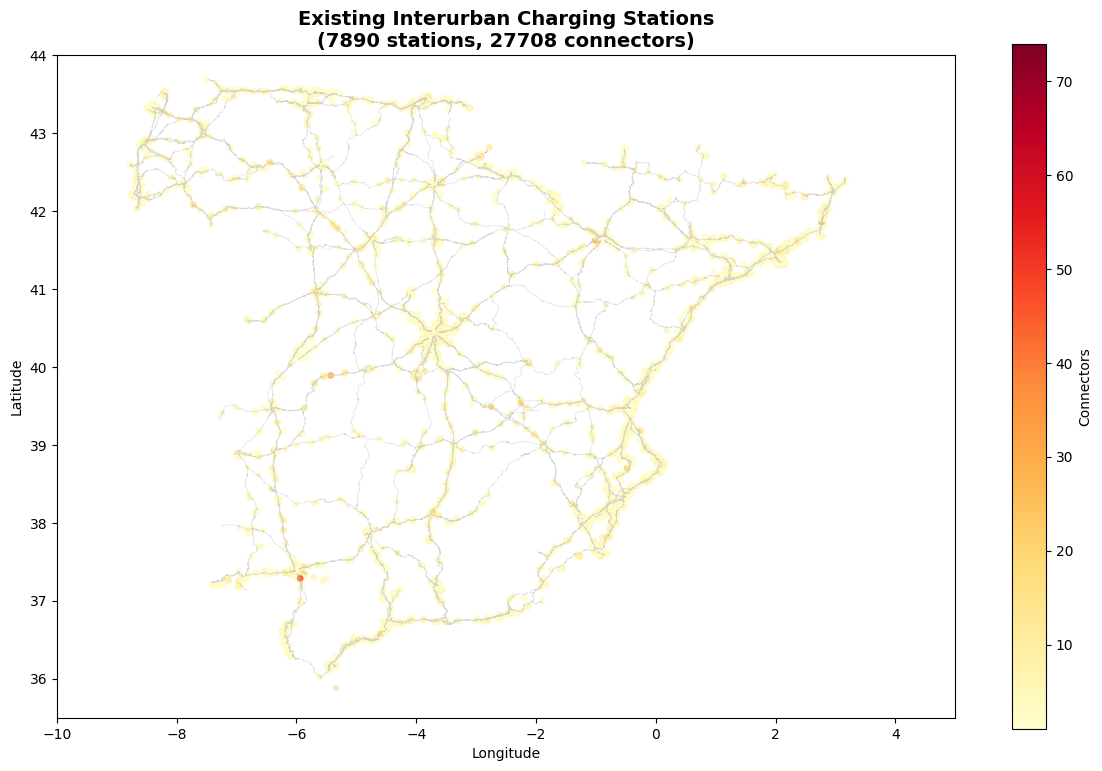

In [11]:
# ── Plot: interurban charging stations ──

if chargers_interurban is not None:
    fig, ax = plt.subplots(1, 1, figsize=(12, 14))

    if roads is not None:
        roads.plot(ax=ax, color='lightgray', linewidth=0.5, alpha=0.5, label='Roads')

    chargers_interurban.plot(
        ax=ax, column='n_connectors', cmap='YlOrRd',
        markersize=15, alpha=0.7, legend=True,
        legend_kwds={'label': 'Connectors', 'shrink': 0.5}
    )

    ax.set_title(
        f"Existing Interurban Charging Stations\n"
        f"({len(chargers_interurban)} stations, "
        f"{chargers_interurban['n_connectors'].sum()} connectors)",
        fontsize=14, fontweight='bold'
    )
    ax.set_xlabel("Longitude"); ax.set_ylabel("Latitude")
    ax.set_xlim(-10, 5); ax.set_ylim(35.5, 44)
    plt.tight_layout(); plt.show()


## 4. Save baseline

In [12]:
# ── Save interurban chargers CSV ──

OUTPUT_PATH = "../data/processed/existing_chargers_interurban.csv"
os.makedirs(os.path.dirname(OUTPUT_PATH), exist_ok=True)

if chargers_interurban is not None:
    export_cols = ['station_id', 'name', 'latitude', 'longitude', 'n_connectors']
    export_df = chargers_interurban[[c for c in export_cols if c in chargers_interurban.columns]].copy()

    export_df.to_csv(OUTPUT_PATH, index=False, encoding='utf-8')
    print(f"Saved {len(export_df)} interurban chargers -> {OUTPUT_PATH}")

    # Key metric for File 1 scorecard
    print(f"\n{'='*55}")
    print(f"  FILE 1 INPUT: total_existing_stations_baseline = {len(export_df)}")
    print(f"{'='*55}")
else:
    print("No data to save.")


Saved 7890 interurban chargers -> ../data/processed/existing_chargers_interurban.csv

  FILE 1 INPUT: total_existing_stations_baseline = 7890
